* DSC640 Final Project 
* Dan Morrow

## Purpose
This document explains the Python analysis that supports the final DSC640 childcare affordability project. The coding portion is intended to make the calculations behind the final visuals reproducible. It does not create a separate analytical story; it supports the same two-child childcare burden story used across the PowerPoint, infographic, and dashboard/notebook mediums.

## Data Used
The analysis uses the National Database of Childcare Prices for 2008 through 2018. The project focuses on county-level center-based infant care, center-based preschool care, geography, year, and county median household income.
The main two-child scenario represents one infant and one preschool-aged child in center-based care at the same time.


## Load and Inspect Dataset

The National Database of Childcare Prices contains county-level childcare price, demographic, income, and workforce information across multiple years. I loaded the dataset and reviewed its size, column names, and the first five rows to understand its structure before beginning the two-child childcare analysis.

Output: The dataset contains 34,567 rows and 227 columns. The first records are for Autauga County, Alabama, beginning in 2008, confirming that the dataset is organized at the county-year level.

In [36]:
import pandas as pd

#Load childcare dataset
df = pd.read_excel("nationaldatabaseofchildcareprices.xlsx")

#Output dataset size
print("Dataset shape:", df.shape)

#Output first three rows
df.head(3)

Dataset shape: (34567, 227)


,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0


Select the Relevant Columns

Next step, narrow down the dataset to only the fields needed, which are related to location, year, household income, infant care, and preschool care.

The selected fields are:

* State_Name
* State_Abbreviation
* County_Name
* County_FIPS_Code
* StudyYear
* MHI
* MCInfant
* MCPreschool

Output: The focused dataset contains the location, year, household income, infant care, and preschool care fields needed for the analysis.

In [38]:
#Select relevant columns
childcare = df[
    [
        "State_Name",
        "State_Abbreviation",
        "County_Name",
        "County_FIPS_Code",
        "StudyYear",
        "MHI",
        "MCInfant",
        "MCPreschool"
    ]
]

#Output selected data
childcare.head(3)

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,MHI,MCInfant,MCPreschool
0,Alabama,AL,Autauga County,1001,2008,50837.0,104.95,85.92
1,Alabama,AL,Autauga County,1001,2009,51463.0,105.11,87.59
2,Alabama,AL,Autauga County,1001,2010,53255.0,105.28,89.26


## Check for Missing Values

Next step, check the selected fields for missing values before calculating the annual childcare costs and two-child burden.

Output: The location, year, and household income fields have no missing values. MCInfant and MCPreschool each contain 10,974 missing values, so those records will need to be removed before calculating the two-child childcare measures.

In [6]:
#Check missing values
childcare.isnull().sum()

State_Name                0
State_Abbreviation        0
County_Name               0
County_FIPS_Code          0
StudyYear                 0
MHI                       0
MHI_2018                  0
MCInfant              10974
MCPreschool           10974
dtype: int64

## Check Missing Childcare Values by Year

Next step, check how the missing infant and preschool childcare values are distributed across the years before removing any records.

Output: Missing childcare values are present in every year from 2008 through 2018, with the largest number occurring in 2008 at 1,718 records. The number generally decreases over time, reaching 782 records in 2018. MCInfant and MCPreschool also have the same number of missing values within each year.

This means the missing data isn’t limited to one particular year. Since both childcare fields are required to calculate the two-child cost, records missing either value can be removed from the two-child analysis. The larger amount of missing data in earlier years should still be kept in mind when interpreting the trend.

In [7]:
#Check missing childcare values by year
childcare.groupby("StudyYear")[["MCInfant", "MCPreschool"]].apply(
    lambda x: x.isnull().sum()
)

,MCInfant,MCPreschool
StudyYear,,
2008,1718,1718
2009,1242,1242
2010,1152,1152
2011,1151,1151
2012,1090,1090
2013,1069,1069
2014,819,819
2015,744,744
2016,501,501


## Remove Missing Childcare Values

Next step, remove records missing either infant or preschool childcare prices since both values are needed to calculate the two-child cost.

Output: After removing records with missing MCInfant or MCPreschool values, the cleaned dataset contains 23,593 rows and 8 columns. The original selected dataset remains unchanged, while childcare_clean will be used for the remaining calculations.

In [39]:
#Remove missing childcare values
childcare_clean = childcare.dropna(
    subset=["MCInfant", "MCPreschool"]
).copy()

#Output cleaned dataset size
childcare_clean.shape

(23593, 8)

## Annualize Infant and Preschool Childcare Costs

Next step, convert the weekly infant and preschool childcare prices into annual costs by multiplying each value by 52.

Output: The annualized values are now available for each county-year record. For example, Autauga County, Alabama shows annual infant care increasing from 5,457.40 in 2008 to 5,491.72 in 2012, while annual preschool care increases from 4,467.84 to 4,815.20 over the same period.

In [11]:
#Annualize childcare costs
childcare_clean["Annual_Infant"] = childcare_clean["MCInfant"] * 52
childcare_clean["Annual_Preschool"] = childcare_clean["MCPreschool"] * 52

#Output annual childcare costs
childcare_clean[
    ["State_Name", "County_Name", "StudyYear", "Annual_Infant", "Annual_Preschool"]
].head()

,State_Name,County_Name,StudyYear,Annual_Infant,Annual_Preschool
0,Alabama,Autauga County,2008,5457.40,4467.84
1,Alabama,Autauga County,2009,5465.72,4554.68
2,Alabama,Autauga County,2010,5474.56,4641.52
3,Alabama,Autauga County,2011,5483.40,4728.36
4,Alabama,Autauga County,2012,5491.72,4815.20


## Create the Two-Child Cost

Next step, combine the annual infant and preschool childcare costs to create the total annual cost for a household with one infant and one preschool-aged child in care at the same time.

Output: The two-child childcare cost is now available for each county-year record. For example, Autauga County, Alabama increases from $9,925.24 in 2008 to $10,306.92 in 2012.

In [12]:
#Calculate two-child childcare cost
childcare_clean["Two_Child_Cost"] = (
    childcare_clean["Annual_Infant"] +
    childcare_clean["Annual_Preschool"]
)

#Output two-child cost
childcare_clean[
    ["State_Name", "County_Name", "StudyYear", "Two_Child_Cost"]
].head()

,State_Name,County_Name,StudyYear,Two_Child_Cost
0,Alabama,Autauga County,2008,9925.24
1,Alabama,Autauga County,2009,10020.40
2,Alabama,Autauga County,2010,10116.08
3,Alabama,Autauga County,2011,10211.76
4,Alabama,Autauga County,2012,10306.92


## Calculate the Two-Child Childcare Burden

Next step, compare the annual two-child childcare cost to county median household income to measure how much of household income the childcare cost represents.

Output: The childcare burden is now calculated for each county-year record. For example, Autauga County, Alabama shows a two-child childcare burden of about 19.5% in 2008, remaining close to 19% through 2012.

In [13]:
#Calculate childcare burden
childcare_clean["Burden"] = (
    childcare_clean["Two_Child_Cost"] /
    childcare_clean["MHI"]
) * 100

#Output childcare burden
childcare_clean[
    ["State_Name", "County_Name", "StudyYear", "Two_Child_Cost", "MHI", "Burden"]
].head()

,State_Name,County_Name,StudyYear,Two_Child_Cost,MHI,Burden
0,Alabama,Autauga County,2008,9925.24,50837.0,19.523654
1,Alabama,Autauga County,2009,10020.40,51463.0,19.471076
2,Alabama,Autauga County,2010,10116.08,53255.0,18.995550
3,Alabama,Autauga County,2011,10211.76,53899.0,18.946103
4,Alabama,Autauga County,2012,10306.92,53773.0,19.167463


## Calculate the 2018 National County Medians

The next step is to isolate the 2018 records and calculate the county medians used throughout the final project.

Output: Across counties in 2018, the median annual infant childcare cost is 7,987.20, the median annual preschool cost is 6,500.00, and the median two-child cost is 14,850.16. The median two-child burden is 29.7% of county median household income.

In [14]:
#Filter 2018 data
childcare_2018 = childcare_clean[
    childcare_clean["StudyYear"] == 2018
]

#Calculate 2018 medians
childcare_2018[
    ["Annual_Infant", "Annual_Preschool", "Two_Child_Cost", "Burden"]
].median()

Annual_Infant        7987.200000
Annual_Preschool     6500.000000
Two_Child_Cost      14850.160000
Burden                 29.662438
dtype: float64

## Count 2018 Counties with Usable Data

The next step is to count the number of unique counties included in the 2018 analysis after removing records with missing infant or preschool childcare prices.

Output: The 2018 analysis contains 2,360 counties with usable childcare cost and household income data.

In [40]:
#Count 2018 counties with usable data
county_count_2018 = childcare_2018["County_FIPS_Code"].nunique()

#Output county count
county_count_2018

2360

## Analyze the 2008–2018 Two-Child Cost Trend

Next step, calculate the median two-child childcare cost for each year from 2008 through 2018 to see how the cost changes over time.

Output: The median two-child childcare cost increases from $11,828.18 in 2008 to $14,850.16 in 2018. The trend generally moves upward across the period, with a small decrease in 2016 before increasing again in 2017 and 2018.

In [15]:
#Calculate yearly median two-child cost
yearly_cost = childcare_clean.groupby("StudyYear")[
    "Two_Child_Cost"
].median()

#Output yearly median cost
yearly_cost

StudyYear
2008    11828.18
2009    11804.00
2010    12151.88
2011    12466.22
2012    12630.80
2013    13018.72
2014    13130.00
2015    13524.16
2016    13174.72
2017    13887.64
2018    14850.16
Name: Two_Child_Cost, dtype: float64

## Calculate the 2008–2018 Percentage Increase

Next step, calculate the percentage increase in the median two-child childcare cost from 2008 to 2018.

Output: The median two-child childcare cost increased by approximately 25.5% from 2008 to 2018.

In [17]:
#Calculate percentage increase
percent_increase = (
    (yearly_cost.loc[2018] - yearly_cost.loc[2008]) /
    yearly_cost.loc[2008]
) * 100

#Output percentage increase
percent_increase

np.float64(25.548985558217748)

## Analyze State-Level Childcare Burden in 2018

Next step, calculate the median two-child childcare burden for each state in 2018 and rank the states from highest to lowest.

Output: Massachusetts has the highest median two-child childcare burden at 41.4%, followed by Vermont at 39.8%, New York at 39.0%, California at 38.7%, and Washington at 38.1%. Several states have a median burden above one-third of household income, showing that childcare affordability pressure varies significantly by location.

In [42]:
#Calculate state median burden
state_burden = childcare_2018.groupby("State_Name")[
    "Burden"
].median().sort_values(ascending=False)

#Output states used in final visual
state_burden.head(7).round(1)

State_Name
Massachusetts    41.4
Vermont          39.8
New York         39.0
California       38.7
Washington       38.1
Alaska           37.0
Oregon           36.0
Name: Burden, dtype: float64

## Analyze County-Level Childcare Burden in 2018

Next step, rank the 2018 counties by two-child childcare burden to identify the areas with the highest affordability pressure.

Output: Bronx County, New York has the highest two-child childcare burden at about 93.0% of county median household income. Allendale County, South Carolina and Milwaukee County, Wisconsin are both just above 63%, followed by Kings County, New York at 62.1% and Humboldt County, California at 56.6%. These results show that some counties experience much more severe childcare affordability pressure than the national median.

In [43]:
#Rank counties by childcare burden
county_burden = childcare_2018[
    ["State_Name", "County_Name", "Two_Child_Cost", "MHI", "Burden"]
].sort_values("Burden", ascending=False)

#Output counties used in final visual
county_burden.head(6).round(2)

,State_Name,County_Name,Two_Child_Cost,MHI,Burden
20139,New York,Bronx County,35401.08,38085.0,92.95
25507,South Carolina,Allendale County,15535.00,24560.0,63.25
33972,Wisconsin,Milwaukee County,30784.00,48742.0,63.16
20370,New York,Kings County,34789.04,56015.0,62.11
2176,California,Humboldt County,25756.12,45528.0,56.57
11735,Kentucky,McCreary County,12697.36,23273.0,54.56


## Count High-Burden Counties

Next step, count how many 2018 counties have a two-child childcare burden at or above 30% and 40% of county median household income.

Output: In 2018, 1,138 counties have a two-child childcare burden at or above 30% of county median household income, and 195 counties are at or above 40%. These counts are used in the dashboard to show how widespread high childcare affordability pressure is.

In [24]:
#Count high-burden counties
high_burden_30 = (childcare_2018["Burden"] >= 30).sum()
high_burden_40 = (childcare_2018["Burden"] >= 40).sum()

#Output burden counts
high_burden_30, high_burden_40

(np.int64(1138), np.int64(195))

## Milwaukee County Drilldown

Next step, using Milwaukee County, Wisconsin as an example to show how the national childcare burden can look very different at the county level. Milwaukee County is included because it is one of the higher-burden counties in the 2018 analysis and is also used as the local dashboard example.

Output: In 2018, Milwaukee County has an annual infant childcare cost of 16,224, an annual preschool childcare cost of 14,560, and a combined two-child cost of 30,784. With a county median household income of 48,742, the two-child childcare burden is about 63.2%. This is more than double the national median burden of 29.7%, which makes Milwaukee County a clear example of how childcare affordability pressure can vary by location.

In [26]:
#Filter Milwaukee County
milwaukee = childcare_2018[
    (childcare_2018["State_Name"] == "Wisconsin") &
    (childcare_2018["County_Name"] == "Milwaukee County")
]

#Output Milwaukee County values
milwaukee[
    [
        "Annual_Infant",
        "Annual_Preschool",
        "Two_Child_Cost",
        "MHI",
        "Burden"
    ]
]

,Annual_Infant,Annual_Preschool,Two_Child_Cost,MHI,Burden
33972,16224.0,14560.0,30784.0,48742.0,63.157031


## Visualize the Two-Child Cost Trend

Next step, create a line chart showing how the median two-child childcare cost changes from 2008 through 2018. This visual supports the trend used in the final PowerPoint and makes the increase over time easier to see.

Output: The chart shows a clear overall increase in the median two-child childcare cost, rising from about 11,828 in 2008 to 14,850 in 2018. There is a small decrease in 2009 and another dip in 2016, but the overall direction is upward, with the sharpest increase occurring between 2017 and 2018.

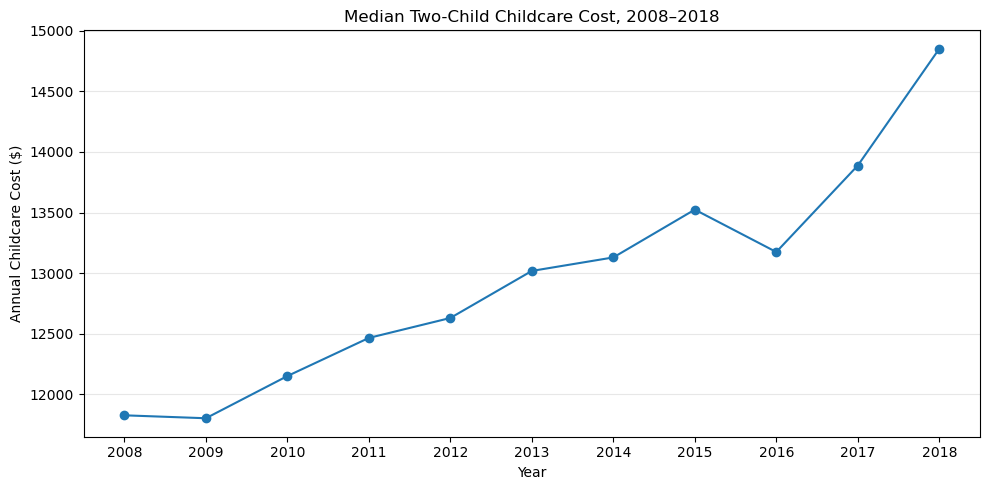

In [28]:
import matplotlib.pyplot as plt

#Create two-child cost trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_cost.index, yearly_cost.values, marker="o")

plt.title("Median Two-Child Childcare Cost, 2008–2018")
plt.xlabel("Year")
plt.ylabel("Annual Childcare Cost ($)")
plt.xticks(yearly_cost.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

#Output trend
plt.show()

## Visualize State-Level Childcare Burden

Next step, create a bar chart showing the states with the highest median two-child childcare burden in 2018.

Output: The chart shows that Massachusetts has the highest median burden at about 41.4%, followed by Vermont, New York, California, and Washington. All ten states shown have a median burden above roughly 34% of county median household income, which reinforces that childcare affordability pressure is especially high in certain parts of the country.

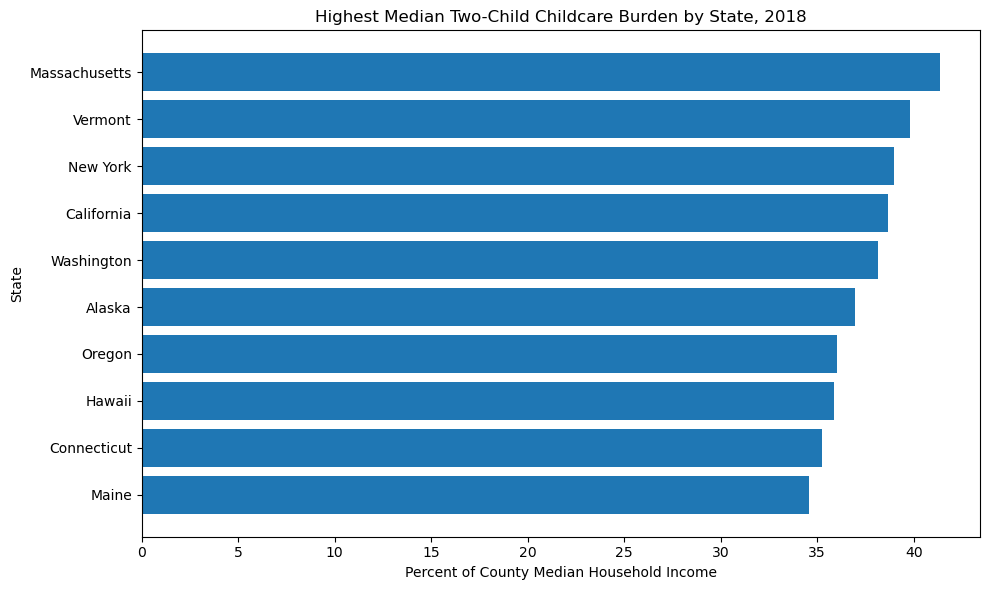

In [29]:
#Create state burden chart
top_states = state_burden.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_states.index, top_states.values)

plt.title("Highest Median Two-Child Childcare Burden by State, 2018")
plt.xlabel("Percent of County Median Household Income")
plt.ylabel("State")
plt.tight_layout()

#Output state burden chart
plt.show()

## Visualize County-Level Childcare Burden

Next step, create a bar chart showing the counties with the highest two-child childcare burden in 2018.

Output: The chart shows that Bronx County, NY has the highest two-child childcare burden at about 93.0% of county median household income. Allendale County, SC and Milwaukee County, WI are both just above 63%, followed by Kings County, NY at about 62.1%. Adding the state abbreviation makes the county comparisons clearer and gives the audience more geographic context.

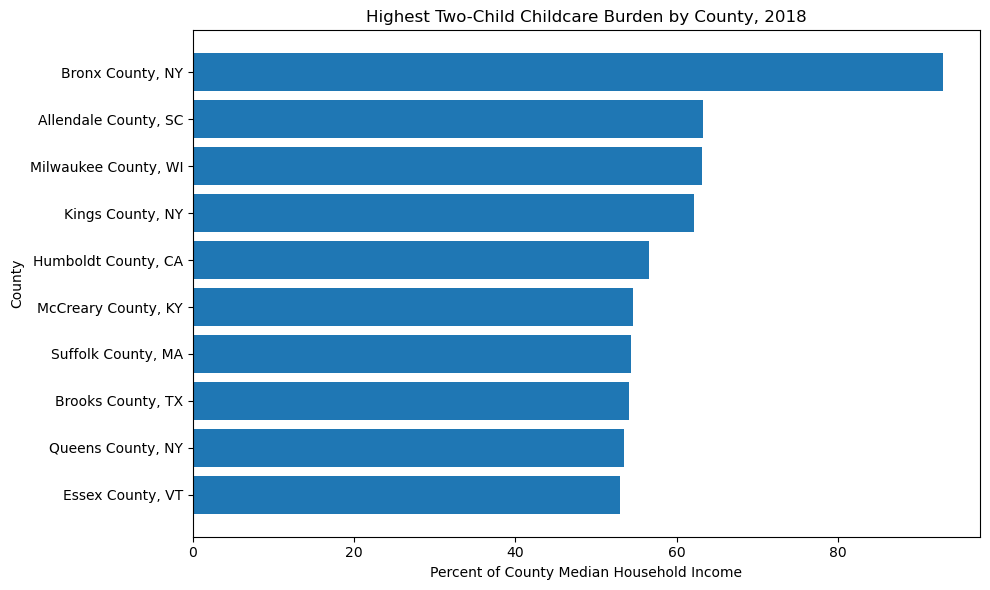

In [33]:
#Create county burden chart
top_counties = childcare_2018[
    ["County_Name", "State_Abbreviation", "Burden"]
].sort_values("Burden", ascending=False).head(10).copy()

#Create county and state labels
top_counties["County_State"] = (
    top_counties["County_Name"] + ", " +
    top_counties["State_Abbreviation"]
)

top_counties = top_counties.sort_values("Burden")

plt.figure(figsize=(10, 6))
plt.barh(top_counties["County_State"], top_counties["Burden"])

plt.title("Highest Two-Child Childcare Burden by County, 2018")
plt.xlabel("Percent of County Median Household Income")
plt.ylabel("County")
plt.tight_layout()

#Output county burden chart
plt.show()

## Visualize the 2018 Childcare Cost Comparison

Next step, create a bar chart comparing the median annual infant care, preschool care, and combined two-child cost in 2018.

Output: The chart shows that median annual infant care is about 7,987, preschool care is about 6,500, and the combined two-child cost reaches about 14,850. The comparison makes it clear how quickly childcare costs increase when a household has two young children in care at the same time.

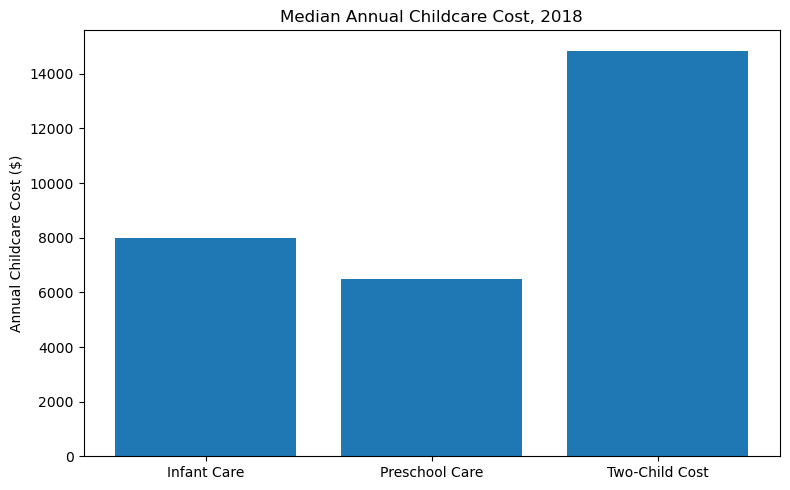

In [35]:
#Create 2018 cost comparison
cost_comparison = childcare_2018[
    ["Annual_Infant", "Annual_Preschool", "Two_Child_Cost"]
].median()

cost_comparison.index = [
    "Infant Care",
    "Preschool Care",
    "Two-Child Cost"
]

plt.figure(figsize=(8, 5))
plt.bar(cost_comparison.index, cost_comparison.values)

plt.title("Median Annual Childcare Cost, 2018")
plt.ylabel("Annual Childcare Cost ($)")
plt.tight_layout()

#Output cost comparison
plt.show()

## Summary

The analysis shows that two-child childcare costs represent a significant financial burden for many families. In 2018, the median annual infant care cost is about 7,987, preschool care is about 6,500, and the combined two-child cost is about 14,850. The median burden equals about 29.7% of county median household income.

The median two-child cost increased by about 25.5% from 2008 to 2018, showing a clear long-term increase in the combined cost. The burden varies significantly by location, with Massachusetts having the highest state median burden at about 41.4% and Bronx County, NY reaching about 93.0%.

The overall story is that childcare affordability is not only a household budgeting issue. The size and geographic variation of the burden make it relevant to workforce participation, employer retention, and local economic planning.